# Prueba Chi-cuadrado: Independencia entre Variables Categoricas

## Objetivo

La prueba chi-cuadrado de independencia responde una pregunta fundamental: **dos variables categoricas estan asociadas o son independientes entre si?**

## Hipotesis

| | Descripcion |
|---|---|
| **H0 (Hipotesis nula)** | Las dos variables son **independientes**. No existe asociacion entre ellas. |
| **H1 (Hipotesis alternativa)** | Las dos variables **no son independientes**. Existe una asociacion significativa. |

## Que significa "independencia"?

Dos variables categoricas son independientes cuando conocer el valor de una **no cambia** la probabilidad de la otra.

**Ejemplo concreto:** Supongamos que queremos saber si fumar esta asociado con sufrir un accidente cerebrovascular (stroke).

- Si las variables son **independientes**: `P(Stroke | Fumador) = P(Stroke | No Fumador) = P(Stroke)`
  - Es decir, la proporcion de strokes es la misma sin importar si la persona fuma o no.
- Si las variables **no son independientes**: `P(Stroke | Fumador) != P(Stroke | No Fumador)`
  - La proporcion de strokes difiere entre fumadores y no fumadores, lo que sugiere una asociacion.

La prueba chi-cuadrado compara las frecuencias **observadas** en los datos con las frecuencias **esperadas** bajo el supuesto de independencia. Si la diferencia es lo suficientemente grande, rechazamos H0.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chi2, fisher_exact
import warnings

# Configuracion de estilo
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

np.random.seed(42)
print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


## Ejemplo paso a paso: Tabla de contingencia 2x2

Supongamos un estudio con **500 pacientes** donde registramos dos variables:
- **Fumador**: Si / No
- **Stroke**: Si / No

### Tabla de frecuencias observadas (O)

|  | Stroke = Si | Stroke = No | Total fila |
|---|---|---|---|
| **Fumador = Si** | 45 | 155 | 200 |
| **Fumador = No** | 30 | 270 | 300 |
| **Total columna** | 75 | 425 | **500** |

### Tabla de frecuencias esperadas (E)

Si las variables fueran independientes, la frecuencia esperada de cada celda se calcula como:

$$E_{ij} = \frac{\text{Total fila}_i \times \text{Total columna}_j}{\text{Gran total}}$$

Por ejemplo: `E(Fumador=Si, Stroke=Si) = (200 * 75) / 500 = 30`

### Estadistico chi-cuadrado

$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

Se suma sobre todas las celdas de la tabla. Cuanto mayor sea la diferencia entre lo observado y lo esperado, mayor sera el valor de chi-cuadrado.

In [2]:
# --- Calculo manual de chi-cuadrado ---

# Tabla de frecuencias observadas
observada = np.array([
    [45, 155],   # Fumador = Si: [Stroke=Si, Stroke=No]
    [30, 270]    # Fumador = No: [Stroke=Si, Stroke=No]
])

print("=" * 60)
print("TABLA DE FRECUENCIAS OBSERVADAS (O)")
print("=" * 60)
print(f"{'':>20} {'Stroke=Si':>12} {'Stroke=No':>12} {'Total':>10}")
print("-" * 60)
for i, fila_nombre in enumerate(["Fumador=Si", "Fumador=No"]):
    total_fila = observada[i].sum()
    print(f"{fila_nombre:>20} {observada[i,0]:>12} {observada[i,1]:>12} {total_fila:>10}")
print("-" * 60)
total_col = observada.sum(axis=0)
gran_total = observada.sum()
print(f"{'Total':>20} {total_col[0]:>12} {total_col[1]:>12} {gran_total:>10}")

# Calcular frecuencias esperadas: E_ij = (total_fila_i * total_col_j) / gran_total
totales_fila = observada.sum(axis=1)
totales_col = observada.sum(axis=0)

esperada = np.outer(totales_fila, totales_col) / gran_total

print(f"\n{'=' * 60}")
print("TABLA DE FRECUENCIAS ESPERADAS (E)")
print(f"E_ij = (Total fila_i * Total columna_j) / Gran total")
print("=" * 60)
print(f"{'':>20} {'Stroke=Si':>12} {'Stroke=No':>12}")
print("-" * 60)
for i, fila_nombre in enumerate(["Fumador=Si", "Fumador=No"]):
    print(f"{fila_nombre:>20} {esperada[i,0]:>12.1f} {esperada[i,1]:>12.1f}")

# Calcular cada termino (O-E)^2 / E
print(f"\n{'=' * 60}")
print("DESGLOSE: cada termino (O - E)^2 / E")
print("=" * 60)
etiquetas = [
    ("Fumador=Si, Stroke=Si", 0, 0),
    ("Fumador=Si, Stroke=No", 0, 1),
    ("Fumador=No, Stroke=Si", 1, 0),
    ("Fumador=No, Stroke=No", 1, 1),
]

chi2_total = 0
for nombre, i, j in etiquetas:
    termino = (observada[i, j] - esperada[i, j]) ** 2 / esperada[i, j]
    chi2_total += termino
    print(f"  {nombre:>30}: ({observada[i,j]} - {esperada[i,j]:.1f})^2 / {esperada[i,j]:.1f} = {termino:.4f}")

print(f"\n  >>> Chi-cuadrado total (manual) = {chi2_total:.4f}")

# Verificacion con scipy
print(f"\n{'=' * 60}")
print("VERIFICACION CON scipy.stats.chi2_contingency")
print("=" * 60)
stat, p_value, dof, expected_scipy = chi2_contingency(observada, correction=False)
print(f"  Estadistico chi2 : {stat:.4f}")
print(f"  Grados de libertad: {dof}")
print(f"  Valor p           : {p_value:.6f}")
print(f"  Alfa (0.05)       : {'Rechazamos H0' if p_value < 0.05 else 'No rechazamos H0'}")
print(f"\n  Conclusion: {'Existe asociacion significativa entre fumar y stroke.' if p_value < 0.05 else 'No hay evidencia de asociacion.'}")

TABLA DE FRECUENCIAS OBSERVADAS (O)
                        Stroke=Si    Stroke=No      Total
------------------------------------------------------------
          Fumador=Si           45          155        200
          Fumador=No           30          270        300
------------------------------------------------------------
               Total           75          425        500

TABLA DE FRECUENCIAS ESPERADAS (E)
E_ij = (Total fila_i * Total columna_j) / Gran total
                        Stroke=Si    Stroke=No
------------------------------------------------------------
          Fumador=Si         30.0        170.0
          Fumador=No         45.0        255.0

DESGLOSE: cada termino (O - E)^2 / E
           Fumador=Si, Stroke=Si: (45 - 30.0)^2 / 30.0 = 7.5000
           Fumador=Si, Stroke=No: (155 - 170.0)^2 / 170.0 = 1.3235
           Fumador=No, Stroke=Si: (30 - 45.0)^2 / 45.0 = 5.0000
           Fumador=No, Stroke=No: (270 - 255.0)^2 / 255.0 = 0.8824

  >>> Chi-cuadrado

## Intuicion detras de la formula

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

### Caso 1: Variables independientes (O aproximadamente E)

Si las frecuencias observadas son muy parecidas a las esperadas, cada termino $(O - E)^2 / E$ sera cercano a **cero**. El chi-cuadrado total sera pequeno, y **no rechazamos H0**.

### Caso 2: Variables asociadas (O muy diferente de E)

Si hay una asociacion real, las frecuencias observadas se desviaran notablemente de las esperadas. Los terminos $(O - E)^2 / E$ seran grandes, produciendo un chi-cuadrado alto que cae en la **region de rechazo**.

### Por que dividimos entre E?

La division por $E$ actua como **normalizacion**. Una diferencia de 10 unidades tiene un significado muy distinto si la frecuencia esperada es 20 (diferencia relativa del 50%) que si es 500 (diferencia relativa del 2%). Sin esta normalizacion, las celdas con valores grandes dominarian el estadistico artificialmente.

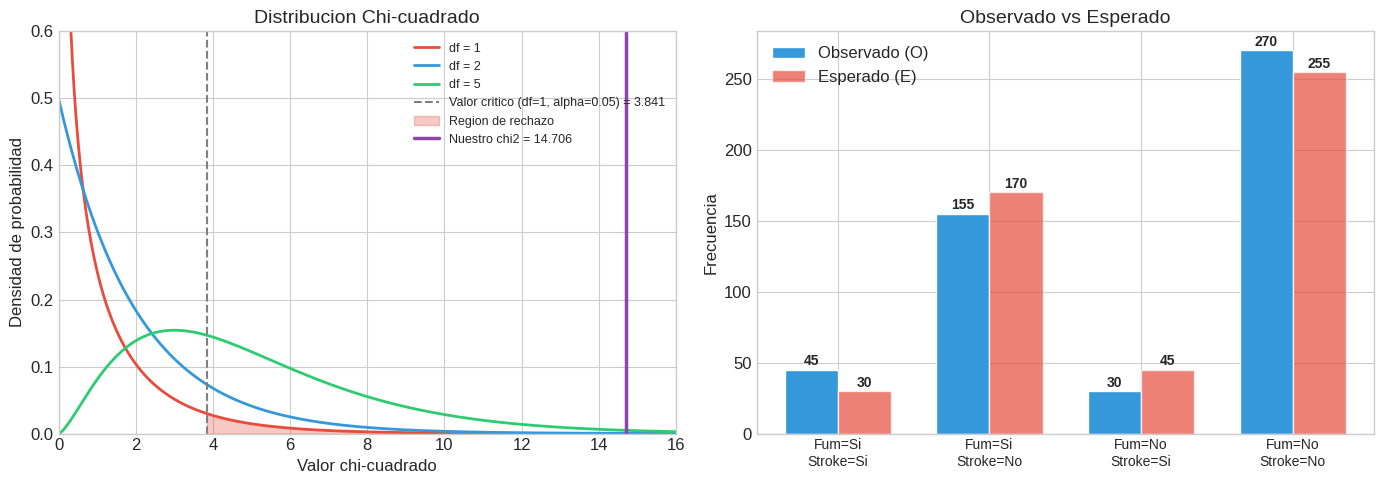

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafico 1: Distribucion chi-cuadrado para distintos grados de libertad ---
ax1 = axes[0]
x = np.linspace(0, 20, 500)

for df_val, color in zip([1, 2, 5], ["#e74c3c", "#3498db", "#2ecc71"]):
    y = chi2.pdf(x, df_val)
    ax1.plot(x, y, label=f"df = {df_val}", color=color, linewidth=2)

# Valor critico para df=1, alpha=0.05
valor_critico = chi2.ppf(0.95, df=1)
ax1.axvline(valor_critico, color="gray", linestyle="--", linewidth=1.5,
            label=f"Valor critico (df=1, alpha=0.05) = {valor_critico:.3f}")

# Region de rechazo para df=1
x_rechazo = np.linspace(valor_critico, 20, 300)
y_rechazo = chi2.pdf(x_rechazo, df=1)
ax1.fill_between(x_rechazo, y_rechazo, alpha=0.3, color="#e74c3c", label="Region de rechazo")

# Marcar nuestro chi2
nuestro_chi2 = chi2_total  # del calculo anterior
ax1.axvline(nuestro_chi2, color="#8e44ad", linestyle="-", linewidth=2.5,
            label=f"Nuestro chi2 = {nuestro_chi2:.3f}")

ax1.set_xlabel("Valor chi-cuadrado")
ax1.set_ylabel("Densidad de probabilidad")
ax1.set_title("Distribucion Chi-cuadrado")
ax1.legend(fontsize=9, loc="upper right")
ax1.set_ylim(0, 0.6)
ax1.set_xlim(0, 16)

# --- Grafico 2: Frecuencias observadas vs esperadas ---
ax2 = axes[1]
categorias = ["Fum=Si\nStroke=Si", "Fum=Si\nStroke=No", "Fum=No\nStroke=Si", "Fum=No\nStroke=No"]
valores_obs = observada.flatten()
valores_esp = esperada.flatten()

x_pos = np.arange(len(categorias))
ancho = 0.35

barras_obs = ax2.bar(x_pos - ancho/2, valores_obs, ancho, label="Observado (O)",
                      color="#3498db", edgecolor="white")
barras_esp = ax2.bar(x_pos + ancho/2, valores_esp, ancho, label="Esperado (E)",
                      color="#e74c3c", alpha=0.7, edgecolor="white")

# Etiquetas en las barras
for barra in barras_obs:
    ax2.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 3,
             f"{int(barra.get_height())}", ha="center", fontsize=10, fontweight="bold")
for barra in barras_esp:
    ax2.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 3,
             f"{barra.get_height():.0f}", ha="center", fontsize=10, fontweight="bold")

ax2.set_xticks(x_pos)
ax2.set_xticklabels(categorias, fontsize=10)
ax2.set_ylabel("Frecuencia")
ax2.set_title("Observado vs Esperado")
ax2.legend()

plt.tight_layout()
plt.show()

## Cuando usar chi-cuadrado y cuando NO

| Situacion | Prueba recomendada | Razon |
|---|---|---|
| Dos variables categoricas, muestras grandes | **Chi-cuadrado de independencia** | Prueba clasica, ampliamente utilizada |
| Dos variables **continuas** | **Correlacion de Pearson / Spearman** | Chi-cuadrado solo aplica a datos categoricos (conteos) |
| Tabla 2x2 con **muestras muy pequenas** (esperadas < 5) | **Prueba exacta de Fisher** | Chi-cuadrado no es fiable con frecuencias esperadas bajas |
| Quiero medir la **fuerza** de la asociacion, no solo si existe | **V de Cramer** | Chi-cuadrado solo dice si hay asociacion, no cuanta |
| Comparar una distribucion observada con una teorica | **Chi-cuadrado de bondad de ajuste** | Variante de chi-cuadrado para una sola variable |
| Datos pareados o repetidos | **Prueba de McNemar** | Chi-cuadrado asume observaciones independientes |

Primeras filas del DataFrame simulado:
      fumador     stroke
0  No fumador  No stroke
1  No fumador  No stroke
2  No fumador  No stroke
3  No fumador  No stroke
4     Fumador  No stroke
5     Fumador  No stroke
6     Fumador  No stroke
7  No fumador  No stroke
8  No fumador     Stroke
9  No fumador  No stroke

Distribucion de fumadores: 
fumador
No fumador    635
Fumador       365
Name: count, dtype: int64

Distribucion de stroke: 
stroke
No stroke    860
Stroke       140
Name: count, dtype: int64

Tabla de contingencia:
stroke      No stroke  Stroke
fumador                      
Fumador           285      80
No fumador        575      60

RESULTADOS DE LA PRUEBA CHI-CUADRADO
  Estadistico chi2  : 28.9030
  Grados de libertad: 1
  Valor p           : 0.000000

  V de Cramer       : 0.1700
  Interpretacion    : Asociacion debil

  Conclusion (alpha=0.05): Rechazamos H0 - Existe asociacion significativa


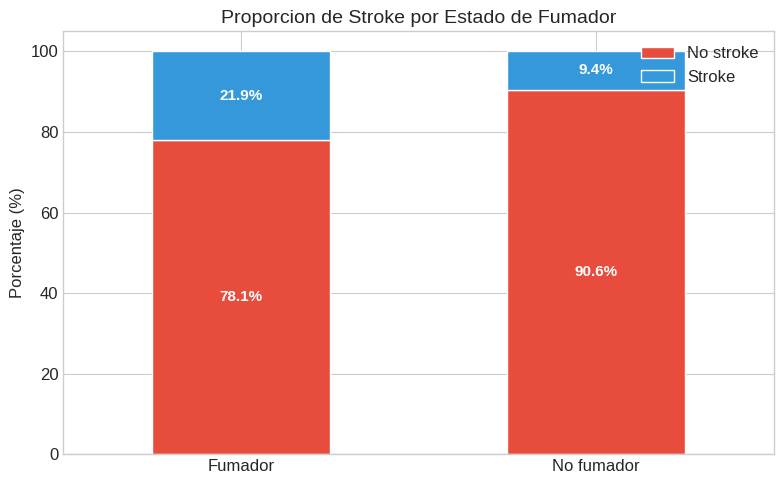

In [4]:
# --- Ejemplo practico: simulacion de 1000 pacientes ---

n_pacientes = 1000

# Simular datos con asociacion real entre fumar y stroke
fumador = np.random.choice(["Fumador", "No fumador"], size=n_pacientes, p=[0.35, 0.65])

# Los fumadores tienen mayor probabilidad de stroke
stroke = np.where(
    fumador == "Fumador",
    np.random.choice(["Stroke", "No stroke"], size=n_pacientes, p=[0.20, 0.80]),
    np.random.choice(["Stroke", "No stroke"], size=n_pacientes, p=[0.08, 0.92])
)

df = pd.DataFrame({"fumador": fumador, "stroke": stroke})

print("Primeras filas del DataFrame simulado:")
print(df.head(10))
print(f"\nDistribucion de fumadores: \n{df['fumador'].value_counts()}")
print(f"\nDistribucion de stroke: \n{df['stroke'].value_counts()}")

# Tabla de contingencia
tabla = pd.crosstab(df["fumador"], df["stroke"])
print(f"\nTabla de contingencia:")
print(tabla)

# Prueba chi-cuadrado
stat, p_val, dof, expected = chi2_contingency(tabla)
print(f"\n{'=' * 50}")
print(f"RESULTADOS DE LA PRUEBA CHI-CUADRADO")
print(f"{'=' * 50}")
print(f"  Estadistico chi2  : {stat:.4f}")
print(f"  Grados de libertad: {dof}")
print(f"  Valor p           : {p_val:.6f}")

# V de Cramer: mide la fuerza de la asociacion
n = tabla.values.sum()
k = min(tabla.shape) - 1
cramers_v = np.sqrt(stat / (n * k))
print(f"\n  V de Cramer       : {cramers_v:.4f}")
print(f"  Interpretacion    : ", end="")
if cramers_v < 0.1:
    print("Asociacion despreciable")
elif cramers_v < 0.3:
    print("Asociacion debil")
elif cramers_v < 0.5:
    print("Asociacion moderada")
else:
    print("Asociacion fuerte")

print(f"\n  Conclusion (alpha=0.05): {'Rechazamos H0 - Existe asociacion significativa' if p_val < 0.05 else 'No rechazamos H0'}")

# --- Grafico: barras apiladas de proporciones ---
fig, ax = plt.subplots(figsize=(8, 5))

prop_tabla = pd.crosstab(df["fumador"], df["stroke"], normalize="index")
prop_tabla.plot(kind="bar", stacked=True, ax=ax, color=["#e74c3c", "#3498db"], edgecolor="white")

ax.set_ylabel("Proporcion")
ax.set_xlabel("")
ax.set_title("Proporcion de Stroke por Estado de Fumador")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="", loc="upper right")

# Agregar etiquetas de porcentaje
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=11, fontweight="bold",
                 color="white")

# Corregir etiquetas (son proporciones, no porcentajes)
# Recalcular con porcentajes
ax.clear()
prop_tabla_pct = pd.crosstab(df["fumador"], df["stroke"], normalize="index") * 100
prop_tabla_pct.plot(kind="bar", stacked=True, ax=ax, color=["#e74c3c", "#3498db"], edgecolor="white")
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("")
ax.set_title("Proporcion de Stroke por Estado de Fumador")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="", loc="upper right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=11, fontweight="bold",
                 color="white")

plt.tight_layout()
plt.show()

## Variantes de la prueba chi-cuadrado y supuestos

### Variantes principales

| Variante | Proposito | Ejemplo |
|---|---|---|
| **Independencia** | Evaluar si dos variables categoricas estan asociadas | Fumar vs Stroke |
| **Bondad de ajuste** | Comparar una distribucion observada contra una distribucion teorica | Verificar si un dado es justo |
| **V de Cramer** | Medir la **fuerza** de la asociacion (complemento de chi-cuadrado) | Valor entre 0 (sin asociacion) y 1 (asociacion perfecta) |

### Supuestos de la prueba chi-cuadrado

1. **Independencia de observaciones**: Cada observacion pertenece a una sola celda de la tabla. No hay datos pareados ni mediciones repetidas.

2. **Frecuencias esperadas suficientes**: Todas las celdas deben tener una frecuencia esperada **>= 5**. Si alguna celda tiene E < 5, la aproximacion chi-cuadrado no es confiable y se recomienda la prueba exacta de Fisher.

3. **Datos de conteo**: La prueba trabaja con frecuencias absolutas (conteos), no con proporciones, porcentajes ni valores continuos.

In [5]:
# --- Cuando chi-cuadrado falla: muestras muy pequenas ---

print("=" * 60)
print("EJEMPLO: Dataset pequeno donde chi-cuadrado NO es apropiado")
print("=" * 60)

# Tabla 2x2 con frecuencias muy bajas
tabla_pequena = np.array([
    [3, 7],    # Fumador: 3 con stroke, 7 sin stroke
    [1, 9]     # No fumador: 1 con stroke, 9 sin stroke
])

print("\nTabla observada (20 pacientes solamente):")
print(f"{'':>20} {'Stroke=Si':>12} {'Stroke=No':>12}")
print("-" * 50)
for i, nombre in enumerate(["Fumador=Si", "Fumador=No"]):
    print(f"{nombre:>20} {tabla_pequena[i,0]:>12} {tabla_pequena[i,1]:>12}")

# Chi-cuadrado (mostrando la advertencia)
stat_p, p_val_p, dof_p, expected_p = chi2_contingency(tabla_pequena, correction=False)

print(f"\nFrecuencias esperadas:")
print(f"{'':>20} {'Stroke=Si':>12} {'Stroke=No':>12}")
print("-" * 50)
for i, nombre in enumerate(["Fumador=Si", "Fumador=No"]):
    print(f"{nombre:>20} {expected_p[i,0]:>12.1f} {expected_p[i,1]:>12.1f}")

# Verificar si alguna esperada es < 5
celdas_bajo_5 = (expected_p < 5).sum()
print(f"\n  ADVERTENCIA: {celdas_bajo_5} celda(s) con frecuencia esperada < 5")
print(f"  Frecuencia esperada minima: {expected_p.min():.1f}")
print(f"  Chi-cuadrado NO es confiable en este caso.")

print(f"\n  Resultado chi-cuadrado (NO confiable):")
print(f"    Estadistico: {stat_p:.4f}, p-valor: {p_val_p:.4f}")

# Alternativa: prueba exacta de Fisher
print(f"\n{'=' * 60}")
print("ALTERNATIVA: Prueba exacta de Fisher")
print("=" * 60)
odds_ratio, p_fisher = fisher_exact(tabla_pequena)
print(f"  Odds ratio   : {odds_ratio:.4f}")
print(f"  Valor p       : {p_fisher:.4f}")
print(f"  Conclusion    : {'Rechazamos H0' if p_fisher < 0.05 else 'No rechazamos H0 - No hay evidencia suficiente de asociacion'}")
print(f"\n  La prueba de Fisher es exacta y no requiere frecuencias esperadas >= 5.")
print(f"  Es la alternativa correcta para tablas 2x2 con muestras pequenas.")

EJEMPLO: Dataset pequeno donde chi-cuadrado NO es apropiado

Tabla observada (20 pacientes solamente):
                        Stroke=Si    Stroke=No
--------------------------------------------------
          Fumador=Si            3            7
          Fumador=No            1            9

Frecuencias esperadas:
                        Stroke=Si    Stroke=No
--------------------------------------------------
          Fumador=Si          2.0          8.0
          Fumador=No          2.0          8.0

  ADVERTENCIA: 2 celda(s) con frecuencia esperada < 5
  Frecuencia esperada minima: 2.0
  Chi-cuadrado NO es confiable en este caso.

  Resultado chi-cuadrado (NO confiable):
    Estadistico: 1.2500, p-valor: 0.2636

ALTERNATIVA: Prueba exacta de Fisher
  Odds ratio   : 3.8571
  Valor p       : 0.5820
  Conclusion    : No rechazamos H0 - No hay evidencia suficiente de asociacion

  La prueba de Fisher es exacta y no requiere frecuencias esperadas >= 5.
  Es la alternativa correcta pa

## Resumen

### Tabla resumen de la prueba chi-cuadrado

| Concepto | Detalle |
|---|---|
| **Proposito** | Evaluar si dos variables categoricas son independientes |
| **Hipotesis nula (H0)** | Las variables son independientes |
| **Estadistico** | $\chi^2 = \sum \frac{(O - E)^2}{E}$ |
| **Frecuencia esperada** | $E_{ij} = \frac{\text{Total fila}_i \times \text{Total columna}_j}{\text{Gran total}}$ |
| **Grados de libertad** | $(r - 1) \times (c - 1)$, donde $r$ = filas, $c$ = columnas |
| **Decision** | Rechazar H0 si $p < \alpha$ (tipicamente $\alpha = 0.05$) |
| **Supuestos** | Observaciones independientes, E >= 5 en todas las celdas, datos de conteo |
| **Alternativa (muestras pequenas)** | Prueba exacta de Fisher |
| **Fuerza de asociacion** | V de Cramer (0 = sin asociacion, 1 = asociacion perfecta) |

### Conceptos clave

- **Chi-cuadrado grande** (p-valor pequeno): Las frecuencias observadas difieren significativamente de las esperadas bajo independencia. Rechazamos H0.
- **Chi-cuadrado pequeno** (p-valor grande): Las frecuencias observadas son compatibles con independencia. No rechazamos H0.
- **No rechazar H0 no significa que las variables sean independientes**, solo que no tenemos evidencia suficiente para afirmar lo contrario.
- **Chi-cuadrado detecta asociacion, no causalidad**. Que fumar y stroke esten asociados no demuestra que fumar cause strokes (aunque en este caso sabemos que si).
- **Siempre verificar los supuestos** antes de interpretar los resultados. Si hay celdas con E < 5, usar Fisher.